 # Simple and Multiple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset("tips")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


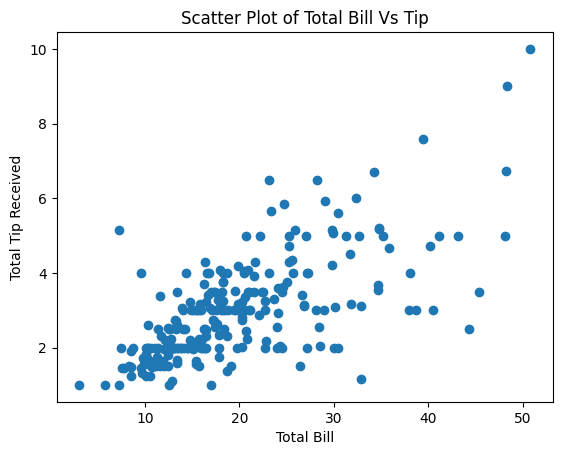

In [14]:
plt.scatter(df.total_bill,df.tip)
# sns.scatterplot(x="total_bill",y="tip",data=df)
plt.xlabel("Total Bill")
plt.ylabel("Total Tip Received")
plt.title("Scatter Plot of Total Bill Vs Tip")
plt.savefig("scatter_tips.png")
plt.show()

In [30]:
import statsmodels.api as sm
X=sm.add_constant(df.total_bill)
Y=df.tip
model=sm.OLS(Y,X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           6.69e-34
Time:                        12:46:47   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.000       0.606       1.235
total_bill     0.1050      0.007     14.260      0.000       0.091       0.120
==============================================================================
Omnibus:                       20.185   Durbin-Watson:                   2.151
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.750
Skew:                           0.443   Prob(JB):                     6.35e-09
Kurtosis:                       4.711   Cond. No.                         53.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
model.params

const         0.920270
total_bill    0.105025
dtype: float64

In [38]:
print(f"tip = {model.params.iloc[0]:.5f} + {model.params.iloc[1]:.5f} * total_bill")

tip = 0.92027 + 0.10502 * total_bill


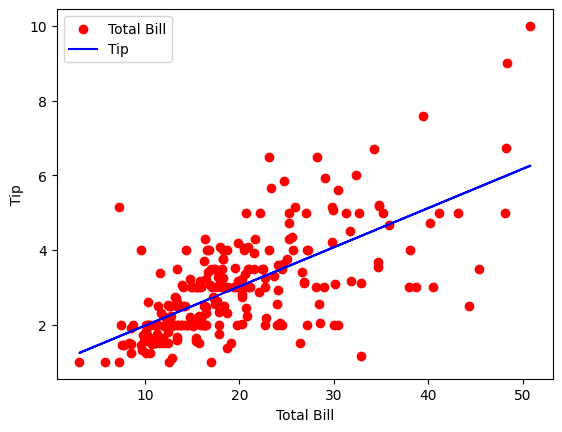

In [52]:
Y_hat=model.predict(X)
plt.scatter(df.total_bill,df.tip,color="r",label="Total Bill")
plt.plot(df.total_bill,Y_hat,color="b",label="Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend()
plt.show()

<Axes: xlabel='total_bill', ylabel='tip'>

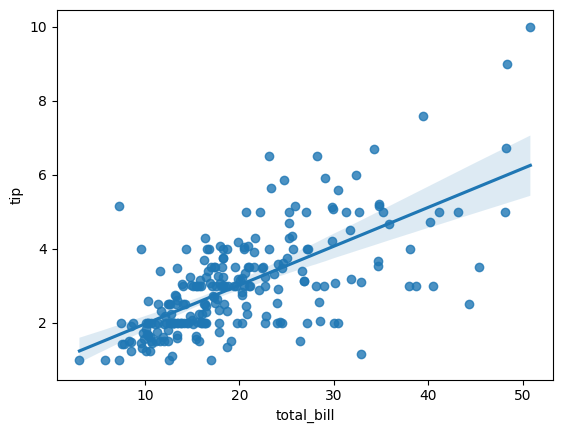

In [53]:
sns.regplot(x="total_bill",y="tip",data=df)

In [54]:
print(f"Coefficient of Determination: {model.rsquared:.4f}")

Coefficient of Determination: 0.4566


In [55]:
Y_hat=model.predict(X)
Resi=Y-Y_hat

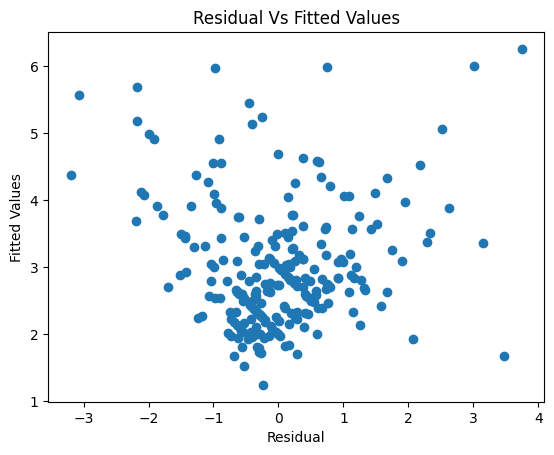

In [58]:
plt.scatter(Resi,Y_hat)
plt.xlabel("Residual")
plt.ylabel("Fitted Values")
plt.title("Residual Vs Fitted Values")
plt.show()

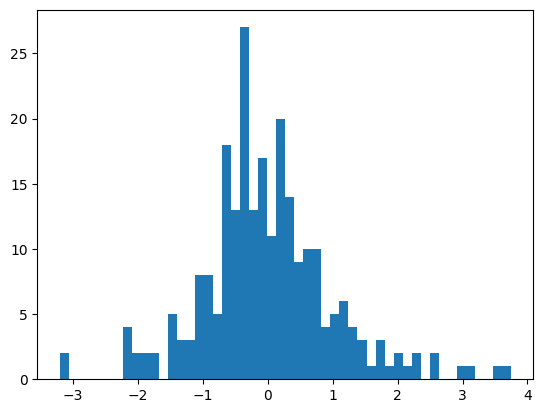

In [61]:
plt.hist(Resi,bins=50)
plt.show()

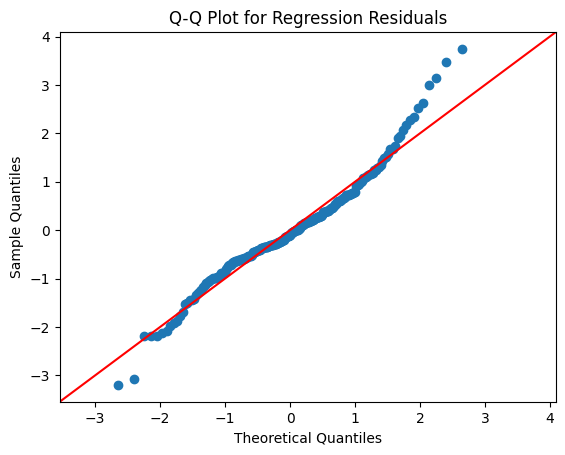

In [64]:
sm.qqplot(Resi,line="45")
plt.title("Q-Q Plot for Regression Residuals")
plt.show()

In [84]:
import scipy.stats as ss
norm_stats, norm_pval = ss.shapiro(Resi)
alpha=.05
print(f"Shapiro test Result: Statistics {norm_stats:0.5f} and pvalue {norm_pval:0.5f}")
if norm_pval < alpha:
    print("Reject Ho: hence Residuals doesn't follow Normal distribution")
else:
    print("Fail to Reject Ho: that is Residuals follow Normal distribution")

Shapiro test Result: Statistics 0.96728 and pvalue 0.00002
Reject Ho: hence Residuals doesn't follow Normal distribution


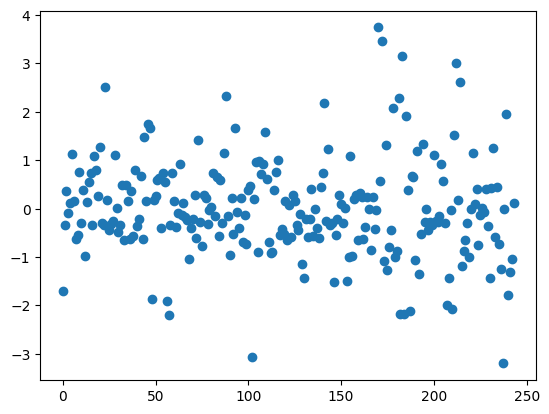

In [88]:
plt.scatter(df.index,Resi)